In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score,classification_report,f1_score,confusion_matrix
from sklearn.model_selection import GridSearchCV,train_test_split,learning_curve
from sklearn.feature_selection import mutual_info_classif

In [3]:
rawdata = load_wine()
X = pd.DataFrame(rawdata['data'],columns=rawdata['feature_names'])
y = pd.DataFrame(rawdata['target'],columns=['target'])

In [4]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [17]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train,y_train)
model

DecisionTreeClassifier(random_state=42)

In [18]:
y_pred = model.predict(X_test)
accuracy_score(y_test,y_pred)

0.9444444444444444

In [15]:
params = {
    'criterion':['entropy','gini'],
    'max_depth':[2,4,6,8,10]
}

In [16]:
grid = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                    param_grid=params,
                    scoring='f1_macro',
                    cv=5)

In [24]:
pd.DataFrame(grid.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.003222,0.001872,0.003097,0.000760,entropy,2,"{'criterion': 'entropy', 'max_depth': 2}",0.932456,0.864062,0.858083,0.860963,0.932660,0.889645,0.035090,5
1,0.001771,0.000956,0.004101,0.001081,entropy,4,"{'criterion': 'entropy', 'max_depth': 4}",0.832067,0.831829,0.858083,0.860963,0.892773,0.855143,0.022515,7
2,0.001891,0.000290,0.002906,0.000760,entropy,6,"{'criterion': 'entropy', 'max_depth': 6}",0.832067,0.831829,0.858083,0.860963,0.892773,0.855143,0.022515,7
3,0.001519,0.000378,0.003296,0.000597,entropy,8,"{'criterion': 'entropy', 'max_depth': 8}",0.832067,0.831829,0.858083,0.860963,0.892773,0.855143,0.022515,7
4,0.002140,0.000568,0.002894,0.000209,entropy,10,"{'criterion': 'entropy', 'max_depth': 10}",0.832067,0.831829,0.858083,0.860963,0.892773,0.855143,0.022515,7
5,0.001595,0.000488,0.002917,0.000165,gini,2,"{'criterion': 'gini', 'max_depth': 2}",0.870370,0.903890,0.893170,0.858699,0.841126,0.873451,0.022748,6
6,0.001607,0.000794,0.003119,0.000748,gini,4,"{'criterion': 'gini', 'max_depth': 4}",0.932692,0.935185,0.893170,0.930481,0.928030,0.923912,0.015552,1
7,0.001892,0.000515,0.003217,0.000671,gini,6,"{'criterion': 'gini', 'max_depth': 6}",0.932692,0.935185,0.893170,0.930481,0.893170,0.916940,0.019465,2
8,0.002058,0.000376,0.003412,0.000115,gini,8,"{'criterion': 'gini', 'max_depth': 8}",0.932692,0.935185,0.893170,0.930481,0.893170,0.916940,0.019465,2
9,0.002266,0.000449,0.002676,0.000531,gini,10,"{'criterion': 'gini', 'max_depth': 10}",0.932692,0.935185,0.893170,0.930481,0.893170,0.916940,0.019465,2


In [17]:
grid.fit(X_train,y_train)
bestgridmodel = grid.best_estimator_
bestgridmodel

c:\Users\georg\anaconda3\envs\Condaenv\Lib\site-packages\numpy\ma\core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


DecisionTreeClassifier(max_depth=4, random_state=42)

In [18]:
y_pred = bestgridmodel.predict(X_test)
accuracy_score(y_test,y_pred)

0.9444444444444444

In [41]:
feature_importance = pd.DataFrame({'feature_names':X.columns,
              'feature_importance':bestgridmodel.feature_importances_}).sort_values(by='feature_importance',ascending=False)

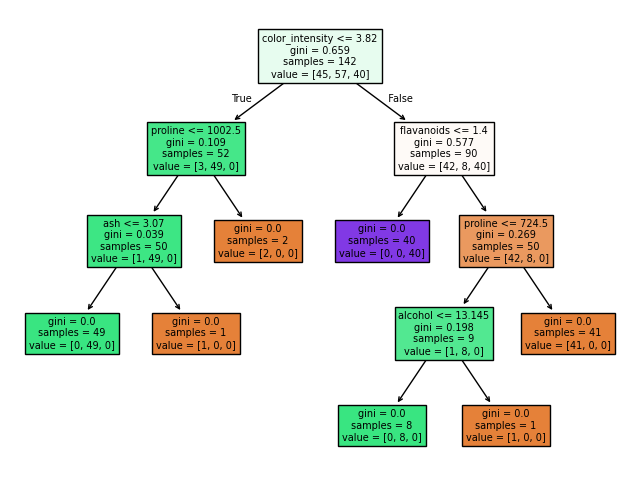

In [49]:
plt.figure(figsize=(8,6))
plot_tree(bestgridmodel,feature_names=X.columns,filled=True)
plt.show()

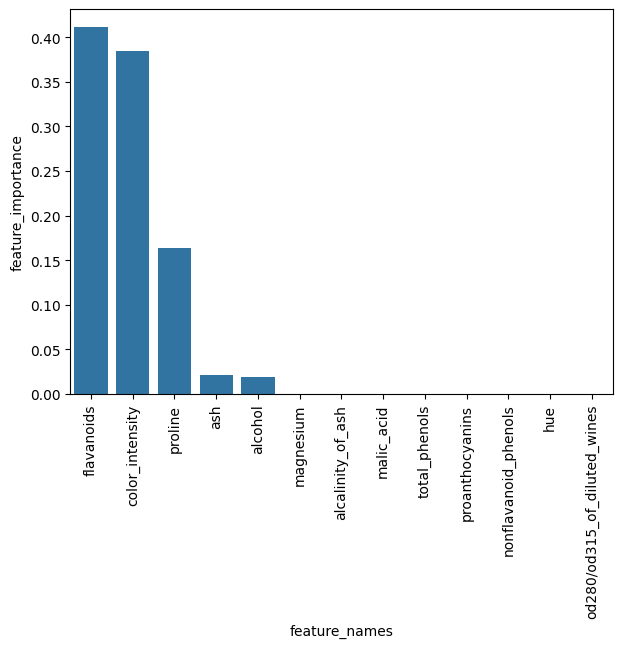

In [44]:
plt.figure(figsize=(7,5))
sns.barplot(data=feature_importance,x='feature_names',y='feature_importance')
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
pd.DataFrame(mutual_info_classif(X,y),
             index=X.columns,columns=['info_score']).sort_values(by='info_score',ascending=False)

c:\Users\georg\anaconda3\envs\Condaenv\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,info_score
flavanoids,0.666049
proline,0.560510
color_intensity,0.552543
od280/od315_of_diluted_wines,0.506611
alcohol,0.464890
hue,0.440860
total_phenols,0.423959
proanthocyanins,0.308493
malic_acid,0.279499
alcalinity_of_ash,0.242563


In [35]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        14
           1       0.93      1.00      0.97        14
           2       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.95      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36



Métriques de Classification

a. Accuracy (Exactitude)

    Définition : Proportion de prédictions correctes par rapport à l'ensemble des prédictions.
    Formule : (Vrai Positifs+Vrai Négatifs)/Total des Prédictions
    Usage : Utile si les classes sont équilibrées, mais peut être trompeur avec des classes déséquilibrées.

b. Precision (Précision)

    Définition : Proportion de vraies prédictions positives parmi toutes les prédictions positives faites par le modèle.
    Formule : Précision=Vrai Positifs/(Vrai Positifs+Faux Positifs)
    Usage : Utilisée lorsque les faux positifs sont coûteux (par exemple, spam detection).

c. Recall (Rappel ou Sensibilité)

    Définition : Proportion de vrais positifs capturés parmi tous les vrais positifs réels.
    Formule : Rappel=Vrai Positifs/(Vrai Positifs+Faux Négatifs)
    Usage : Important lorsque manquer des vrais positifs est coûteux (par exemple, détection de maladie).

d. F1-Score

    Définition : Moyenne harmonique de la précision et du rappel. Représente un bon compromis entre les deux.
    Formule : F1= 2 × (Précision X Rappel / Précision + Rappel) 
    Usage : Utile lorsque vous devez équilibrer précision et rappel, surtout en cas de classes déséquilibrées.

In [36]:
f1_score(y_test,y_pred,average='macro')

np.float64(0.9424740010946907)

In [12]:
np.linspace(0.1,1,10)

array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

In [5]:
train_size, train_score, val_score = learning_curve(estimator=DecisionTreeClassifier(random_state=42),
                                                    X=X_train,
                                                    y=y_train,
                                                    train_sizes=np.linspace(0.1,1,10),
                                                    scoring='f1_macro',
                                                    cv=5)

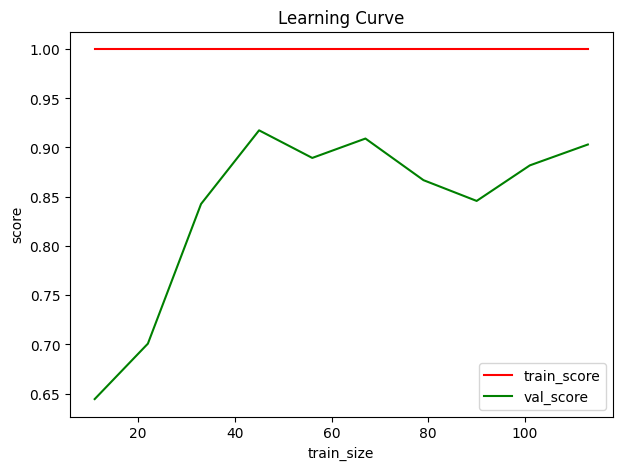

In [11]:
plt.figure(figsize=(7,5))
plt.title('Learning Curve')
plt.plot(train_size,train_score.mean(axis=1),label='train_score',color='red')
plt.plot(train_size,val_score.mean(axis=1),label='val_score',color='green')
plt.xlabel('train_size')
plt.ylabel('score')
plt.legend()
plt.show()


In [20]:
cm = confusion_matrix(y_test,y_pred)
cm

array([[13,  1,  0],
       [ 0, 14,  0],
       [ 1,  0,  7]])

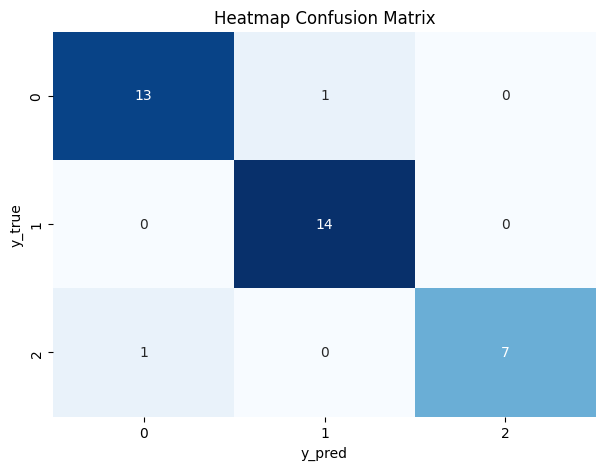

In [22]:
plt.figure(figsize=(7,5))
plt.title('Heatmap Confusion Matrix')
sns.heatmap(cm,cbar=False,cmap='Blues',annot=True)
plt.xlabel('y_pred')
plt.ylabel('y_true')
plt.show()